# CO2 storage in a layered saline aquifer: simulator, surrogates, limits

**The question.** How do permeability, heterogeneity, fluid mobility and the injection schedule control the pressure build-up at the well and the spread of the CO2 plume in a sealed, layered saline aquifer -- and can a cheap machine-learning surrogate, trained on simulations, answer that for a reservoir it has never seen?

**What this notebook is.** The walkthrough of the whole project, in order, end to end. It runs a simulation, then reads the results of a finished run and re-checks the headline numbers. Every output is labelled either

* `[LOADED from the completed study run]` -- read from `results/study/`, produced by `scripts/run_pipeline.py` on 2026-09-20, or
* `[COMPUTED NOW in this notebook session]` -- calculated while you run these cells.

**Plan**

1. Purpose, scope and assumptions
2. Simulation: one injection case, run here
3. Verification: does the simulator solve the right equations?
4. Dataset and the grouped split
5. Surrogate training
6. Held-out evaluation, re-checked here
7. Screening injection schedules, including where it fails
8. Conclusions and limitations

**Everything here comes from two sets of supplied course material**: the *Advanced Subsurface Modelling* lectures (transmissibility, upscaling, IMPES, CO2 Buckley-Leverett, uncertainty) and the *Data Science and Machine Learning* notebooks. No method, dataset or library outside that material is used; `docs/SOURCE_MAP.md` names the file behind each component.

**All data are synthetic**, generated by the simulator in this repository. Nothing is calibrated to, or validated against, a real site.

In [1]:
import sys, json, time
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
from subsurfaceml.config import load_config

CONFIG = 'study'                 # which completed run this notebook reads
cfg = load_config(ROOT / 'config' / f'{CONFIG}.yaml')
S = json.loads((Path(cfg.paths.metrics) / 'summary.json').read_text())
pd.set_option('display.max_colwidth', 80)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3,
                     'font.size': 9, 'figure.constrained_layout.use': True})


def provenance(kind, what):
    """Label every result: read from a finished run, or computed right here."""
    label = {'loaded': 'LOADED from the completed ' + CONFIG + ' run',
             'computed': 'COMPUTED NOW in this notebook session'}[kind]
    print(f'[{label}]  {what}')

provenance('loaded', f"run of {S['config_file']} started {S['started']}, "
           f"{S['total_wall_seconds']/60:.1f} min wall, python "
           f"{S['environment']['python']}, scikit-learn {S['environment']['scikit_learn']}")

[LOADED from the completed study run]  run of config/study.yaml started Sun Sep 20 14:51:49 2026, 47.6 min wall, python 3.11.15, scikit-learn 1.8.0


## 1. Purpose, scope and assumptions

The model is deliberately small, so that every part can be explained and checked. One rate-controlled injector sits at the centre of a sealed, cylindrical compartment split into horizontal layers. Each layer has its own permeability and porosity; there is **no vertical crossflow**, and all layers share **one bottom-hole pressure**, solved together with the pressure field.

What is deliberately left out, and why:

| Left out | Consequence |
|---|---|
| Gravity / buoyancy | the largest omission: no gravity override, so plume rise is not modelled |
| Dissolution and residual trapping | storage security cannot be assessed |
| Capillary pressure (`P_c = 0`) | the supplied material gives no CO2-brine curve (`4-CO2 BL.pdf` p.19) |
| Vertical crossflow between layers | layer rates communicate only through the well |
| Non-radial geometry, faults, wells beyond one | not a field model |

The pressure and plume limits below are **stated assumptions** used to define a screening question. They say nothing about fracture pressure, caprock integrity or leakage, none of which is modelled. Full list: `docs/ASSUMPTIONS.md`.

In [2]:
c = S['config']
print('reservoirs sampled      :', c['scenarios']['n_realisations'])
print('schedules per reservoir :', c['scenarios']['n_schedules_per_realisation'])
print('radial cells / layers   :', c['grid']['n_r'], '/', c['grid']['n_layers'])
print('injection / total [yr]  :', c['schedule']['t_inject_years'], '/',
      c['schedule']['t_total_years'], 'in', c['schedule']['n_periods'], 'rate periods')
print('initial pressure  [MPa] :', c['solver']['p_init_MPa'])
print('assumed limits          :', cfg.optim.p_limit_MPa, 'MPa at the well,',
      cfg.optim.r_plume_limit_m, 'm plume radius')
provenance('loaded', 'configuration of the completed run')

reservoirs sampled      : 220
schedules per reservoir : 4
radial cells / layers   : 60 / 4
injection / total [yr]  : 5.0 / 10.0 in 4 rate periods
initial pressure  [MPa] : 15.0
assumed limits          : 24.0 MPa at the well, 400.0 m plume radius
[LOADED from the completed study run]  configuration of the completed run


## 2. Simulation: one injection case, run here

The solver is IMPES (implicit pressure, explicit saturation) on a radial grid, with upstream mobilities and harmonic face transmissibilities, following `3-IMPES.pdf` and `1-Transmissibility.pdf`. The cell below takes the first held-out reservoir of the finished run, builds its designed schedule and simulates it from scratch, so you can see the two quantities the surrogates later predict: the pressure build-up at the well and the plume radius.

In [3]:
from subsurfaceml.scenarios import sample_realisations, sample_schedules, run_scenario
from subsurfaceml.units import MPA, YEAR

test_ids = S['ml']['split']['test_ids']
reservoirs = {x.realisation_id: x for x in sample_realisations(cfg)}
r = reservoirs[test_ids[0]]                  # a reservoir the models never saw
sched = sample_schedules(cfg, r)[0]          # its first designed schedule
print('reservoir', r.realisation_id, ': k =', round(r.k_median_mD), 'mD,',
      'V_DP =', round(r.V_DP, 2), ', porosity =', round(r.phi_mean, 3),
      ', thickness =', round(r.h_total_m), 'm')
print('injection rates [kg/s]:', np.round(sched['rates_kg_s'], 2))

t0 = time.perf_counter()
out = run_scenario(cfg, r, sched, want_series=True)
row, series = out['row'], out['series']
provenance('computed', f"one simulation in {time.perf_counter()-t0:.1f} s "
           f"(CO2 mass-balance error {row['mass_balance_error']:.1e})")
print('peak pressure build-up    :', round(row['dp_bh_max_Pa']/MPA, 2), 'MPa')
print('plume radius (95% of mass):', round(row['r_plume_m95_m']), 'm')

reservoir

 0 : k = 997 mD, V_DP = 0.42 , porosity = 0.119 , thickness = 36 m
injection rates [kg/s]: [7.8  7.99 7.76 7.11]


[COMPUTED NOW in this notebook session]  one simulation in 13.0 s (CO2 mass-balance error 5.9e-15)
peak pressure build-up    : 12.82 MPa
plume radius (95% of mass): 545 m


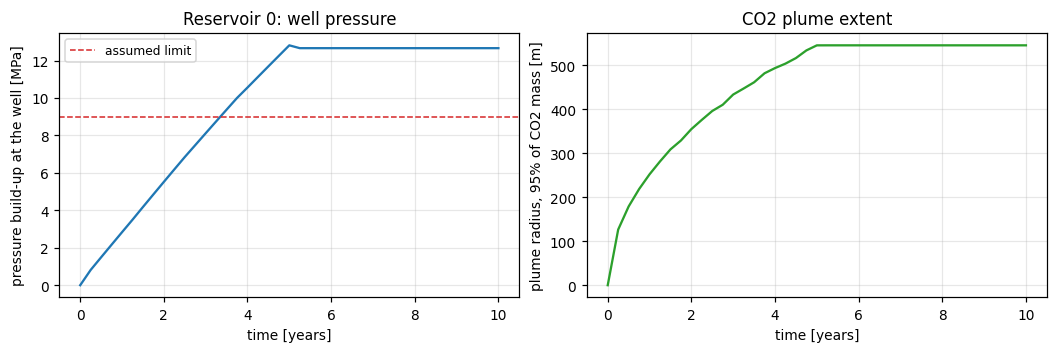

[COMPUTED NOW in this notebook session]  both curves come from the simulation above


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.1))
ax[0].plot(series.t_s/YEAR, series.dp_bh_Pa/MPA, color='tab:blue')
ax[0].axhline(cfg.optim.p_limit_MPa - cfg.solver.p_init_MPa, color='tab:red',
              ls='--', lw=1, label='assumed limit')
ax[0].set_xlabel('time [years]')
ax[0].set_ylabel('pressure build-up at the well [MPa]')
ax[0].set_title(f'Reservoir {r.realisation_id}: well pressure')
ax[0].legend(fontsize=8)
ax[1].plot(series.t_s/YEAR, series.r_plume_m95_m, color='tab:green')
ax[1].set_xlabel('time [years]')
ax[1].set_ylabel('plume radius, 95% of CO2 mass [m]')
ax[1].set_title('CO2 plume extent')
plt.show()
provenance('computed', 'both curves come from the simulation above')

## 3. Verification: does the simulator solve the right equations?

Before any machine learning, the solver is checked against analytical and conservation results taken from the lectures: steady radial flow, the well equation, closed-tank material balance, the Buckley-Leverett/Welge front, CO2 mass balance, saturation bounds, grid and time-step convergence, upscaling bounds, and the common bottom-hole pressure across layers. The pipeline refuses to generate data if any check fails.

In [5]:
verdict = {k: v for k, v in S['validation_verdict'].items() if k != 'ALL_PASS'}
V = pd.Series(verdict, name='pass').to_frame()
print(f"{int(V['pass'].sum())} of {len(V)} verification checks pass")
display(V.T)
provenance('loaded', 'results/study/metrics/validation.json')

18 of 18 verification checks pass


,steady_radial_pressure,well_index_bhp,closed_tank,buckley_leverett_front,buckley_leverett_L1,bl_no_clipping,radial_mass_balance,radial_no_clipping,radial_saturation_bounds,no_odd_even_oscillation,time_step_control_insensitive,upscaling_2x2_bounds,upscaling_parallel_exact,upscaling_series_exact,upscaling_bounds_random,well_common_bhp,well_total_rate_conserved,well_shut_in_no_crossflow
pass,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


[LOADED from the completed study run]  results/study/metrics/validation.json


## 4. Dataset and the grouped split

Reservoir descriptions and injection schedules are drawn by Monte Carlo sampling (`5-Uncertainty.pdf`), and every combination is simulated. The unit of learning is the **reservoir realisation**, not the row: several schedules share one reservoir, so rows are not independent. All splits and all cross-validation folds are therefore grouped by `realisation_id` -- a reservoir is either in training, or in calibration, or in test, never in two.

In [6]:
df = pd.read_csv(Path(cfg.paths.data)/'scenarios_features.csv')
print(len(df), 'simulated cases from', df.realisation_id.nunique(), 'reservoirs')
print('rows per partition :', S['ml']['leakage']['rows'])
print('reservoir overlaps :', S['ml']['leakage']['overlaps'], '(all must be 0)')
print('failed simulations :', S['dataset']['n_failed'],
      '| duplicate input rows:', S['data_quality']['duplicate_input_rows'],
      '| missing values:', S['data_quality']['missing_values_total'])
provenance('loaded', 'results/study/data/scenarios_features.csv')

880 simulated cases from 220 reservoirs
rows per partition : {'train': 496, 'calib': 164, 'test': 220}
reservoir overlaps : {'train_calib': 0, 'train_test': 0, 'calib_test': 0} (all must be 0)
failed simulations : 0 | duplicate input rows: 0 | missing values: 0
[LOADED from the completed study run]  results/study/data/scenarios_features.csv


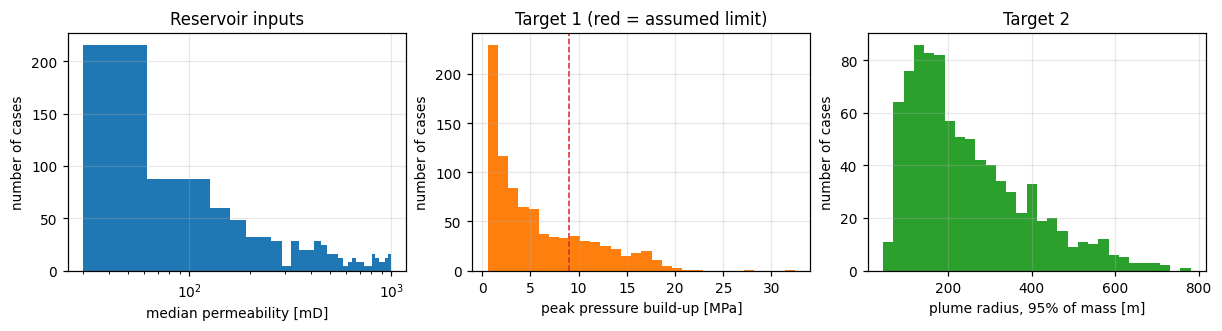

[COMPUTED NOW in this notebook session]  histograms drawn from the loaded dataset


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(11, 2.9))
ax[0].hist(10**df.log10_k_mD, bins=30, color='tab:blue')
ax[0].set_xscale('log'); ax[0].set_xlabel('median permeability [mD]')
ax[0].set_ylabel('number of cases'); ax[0].set_title('Reservoir inputs')
ax[1].hist(df.dp_bh_max_MPa, bins=30, color='tab:orange')
ax[1].axvline(cfg.optim.p_limit_MPa - cfg.solver.p_init_MPa, color='tab:red', ls='--', lw=1)
ax[1].set_xlabel('peak pressure build-up [MPa]'); ax[1].set_ylabel('number of cases')
ax[1].set_title('Target 1 (red = assumed limit)')
ax[2].hist(df.r_plume_m95_m, bins=30, color='tab:green')
ax[2].set_xlabel('plume radius, 95% of mass [m]'); ax[2].set_ylabel('number of cases')
ax[2].set_title('Target 2')
plt.show()
provenance('computed', 'histograms drawn from the loaded dataset')

## 5. Surrogate training

Eleven regression families from the *Data Science and Machine Learning* notebooks (linear, ridge, lasso, elastic net, k-nearest neighbours, SVR, decision tree, random forest, gradient boosting, AdaBoost, XGBoost), plus a mean-value baseline, are each placed in a scikit-learn pipeline (median imputation, standard scaling, model). Each is tuned by randomised search inside **grouped** 4-fold cross-validation on the training reservoirs only, and the family with the lowest cross-validated RMSE is selected and refitted on all training reservoirs. Pressure build-up and plume radius are fitted on a log scale; sweep efficiency is not. The calibration reservoirs are used only for the error band, and the saved models carry a SHA-256 manifest.

Training is not repeated here -- these are the results of the finished run.

In [8]:
rows = []
for t, res in S['ml']['targets'].items():
    rows.append({'target': t, 'unit': res['unit'],
                 'selected family': res['selected_model'],
                 'log-scale fit': res['log_target'],
                 'families compared': len(res['model_comparison_cv_rmse']),
                 'grouped CV RMSE': round(res['cv_rmse_selected'], 4),
                 'CV RMSE unit': res['cv_rmse_units']})
display(pd.DataFrame(rows).set_index('target'))
print('time to tune and fit every family [s]:',
      round(S['speed']['surrogate_training_seconds']))
provenance('loaded', 'model selection from results/study/metrics/summary.json')

,unit,selected family,log-scale fit,families compared,grouped CV RMSE,CV RMSE unit
target,,,,,,
dp_bh_max_MPa,MPa,svr,True,12,1.0069,MPa
r_plume_m95_m,m,elasticnet,True,12,10.1012,m
sweep_efficiency,-,svr,False,12,0.0012,-


time to tune and fit every family [s]: 623
[LOADED from the completed study run]  model selection from results/study/metrics/summary.json


## 6. Held-out evaluation, re-checked here

The test reservoirs were touched once, at the end. Errors are reported in physical units, against a mean-value baseline, together with the measured coverage of the empirical P5-P95 error band.

The second cell does not trust the table: it loads the saved models, re-predicts the held-out rows and recomputes the metrics here. The two sets of numbers should agree to rounding.

In [9]:
rows = []
for t, res in S['ml']['targets'].items():
    rows.append({'target': t, 'unit': res['unit'], 'n test rows': res['test']['n'],
                 'MAE': round(res['test']['MAE'], 4), 'RMSE': round(res['test']['RMSE'], 4),
                 'R2': round(res['test']['R2'], 4),
                 'worst case': round(res['test']['max_error'], 3),
                 'baseline RMSE': round(res['mean_baseline_test']['RMSE'], 4),
                 'band coverage': round(res['error_band']['measured_coverage_test'], 3)})
display(pd.DataFrame(rows).set_index('target'))
print('test reservoirs:', len(S['ml']['split']['test_ids']))
provenance('loaded', 'held-out metrics of the completed study run')

,unit,n test rows,MAE,RMSE,R2,worst case,baseline RMSE,band coverage
target,,,,,,,,
dp_bh_max_MPa,MPa,220,0.4203,1.2373,0.9406,14.839,5.0769,0.877
r_plume_m95_m,m,220,6.5316,10.5104,0.9945,57.054,142.2232,0.909
sweep_efficiency,-,220,0.0008,0.0012,0.9885,0.005,0.0108,0.832


test reservoirs: 55
[LOADED from the completed study run]  held-out metrics of the completed study run


In [10]:
from subsurfaceml.predict import Predictor
from subsurfaceml.features import FEATURES
from subsurfaceml.models import regression_metrics

P = Predictor(cfg)           # verified artifacts; refuses to load a mismatched version
test = df[df.realisation_id.isin(P.manifest['test_realisation_ids'])]
X = test[list(FEATURES)]
check = []
for t, model in P.surrogates.items():
    m = regression_metrics(test[t], model.predict(X), S['ml']['targets'][t]['unit'])
    check.append({'target': t, 'unit': m['unit'], 'n': m['n'],
                  'RMSE recomputed': round(m['RMSE'], 4),
                  'RMSE reported': round(S['ml']['targets'][t]['test']['RMSE'], 4),
                  'R2 recomputed': round(m['R2'], 4),
                  'R2 reported': round(S['ml']['targets'][t]['test']['R2'], 4)})
display(pd.DataFrame(check).set_index('target'))
provenance('computed', 'predictions and metrics recomputed from the saved models')

,unit,n,RMSE recomputed,RMSE reported,R2 recomputed,R2 reported
target,,,,,,
dp_bh_max_MPa,MPa,220,1.2373,1.2373,0.9406,0.9406
r_plume_m95_m,m,220,10.5104,10.5104,0.9945,0.9945
sweep_efficiency,-,220,0.0012,0.0012,0.9885,0.9885


[COMPUTED NOW in this notebook session]  predictions and metrics recomputed from the saved models


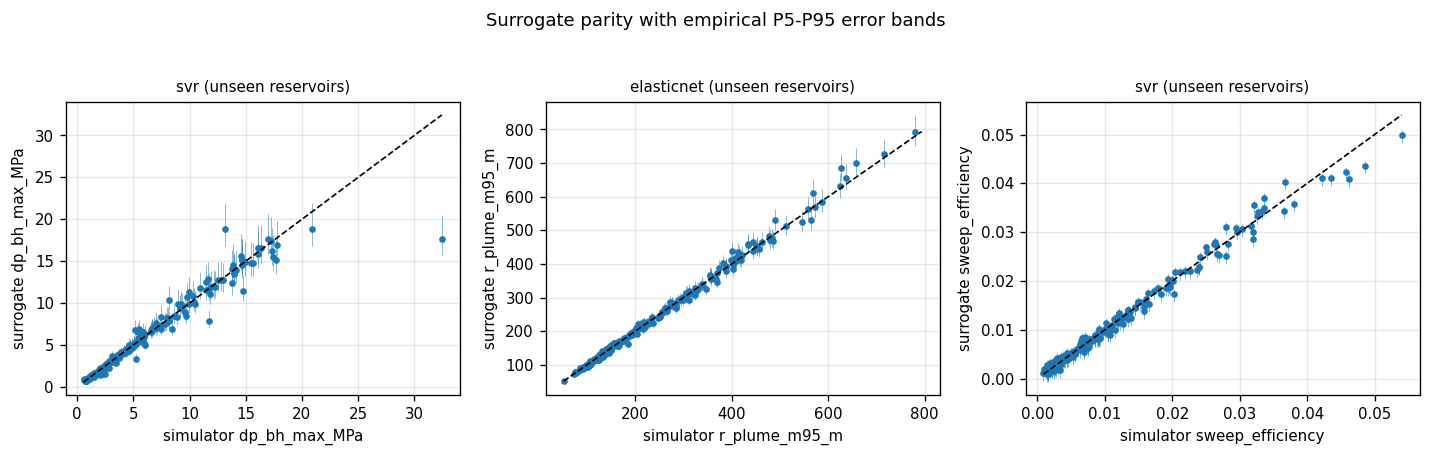

[LOADED from the completed study run]  results/study/figures/06_surrogate_parity.png (predicted vs simulated on held-out reservoirs, physical units)


In [11]:
display(Image(str(Path(cfg.paths.figures)/'06_surrogate_parity.png')))
provenance('loaded', 'results/study/figures/06_surrogate_parity.png '
           '(predicted vs simulated on held-out reservoirs, physical units)')

Where the surrogates are weakest is as important as the average error. The worst tenth of the held-out cases carries a disproportionate share of the total error, and the low-permeability reservoirs are the hardest.

In [12]:
h = S['ml']['targets']['dp_bh_max_MPa']['difficult_cases']
print('share of total absolute error from the worst 10% of cases:',
      f"{100*h['share_of_total_abs_error_from_worst_10pct']:.0f}%")
display(pd.DataFrame(h['by_permeability_tercile']))
provenance('loaded', 'difficult-case analysis, pressure surrogate')

share of total absolute error from the worst 10% of cases: 58%


,k_bin,n,MAE,median_rel_err
0,low k,76,0.783417,0.078869
1,mid k,72,0.243685,0.025478
2,high k,72,0.213766,0.023558


[LOADED from the completed study run]  difficult-case analysis, pressure surrogate


## 7. Screening injection schedules, including where it fails

The intended use of a fast surrogate: sample many candidate schedules for an unseen reservoir, keep those predicted to stay inside the assumed limits, then **re-simulate the shortlist and a constant-rate baseline**, because only the simulator decides. The result is mixed: on the reservoirs where a comparison was possible the median injected mass improves only slightly, and on one low-permeability reservoir every screened schedule -- and the constant-rate baseline -- broke the assumed pressure limit when re-simulated.

In [13]:
o = S['optimisation']
print('reservoirs screened            :', o['n_test_realisations'])
print('median improvement vs baseline :', round(o['median_improvement_pct'], 1), '%')
print('screened schedules re-simulated:', o['n_screened_resimulated'])
print('of those, violating the limit  :', o['n_screened_violating'],
      f"({100*o['screened_violation_rate']:.0f}%)")
per = pd.DataFrame(o['per_realisation']).round(3)
display(per.set_index('realisation_id'))
print('speed-up of a surrogate call over a simulation: '
      f"{S['speed']['speedup_batched']:.0f}x batched, "
      f"{S['speed']['speedup_single_end_to_end']:.0f}x end to end "
      '(excludes data generation and training)')
provenance('loaded', 'screening and re-simulation of the completed study run')

reservoirs screened            : 8
median improvement vs baseline : 1.4 %
screened schedules re-simulated: 24
of those, violating the limit  : 3 (12%)


,baseline_mass_Mt,baseline_feasible_after_resimulation,n_screened_resimulated,n_screened_feasible,best_screened_mass_Mt,best_dp_MPa,best_rplume_m,improvement_pct
realisation_id,,,,,,,,
0,0.601,True,3,3,0.600,6.462,390.387,-0.072
5,0.862,True,3,3,0.874,5.844,385.361,1.412
6,0.226,True,3,3,0.241,8.120,229.380,6.573
13,0.215,True,3,3,0.224,8.058,199.173,3.793
17,0.234,True,3,3,0.243,7.857,165.772,4.148
25,0.638,True,3,3,0.640,4.497,358.931,0.283
36,0.519,False,3,0,NaN,NaN,NaN,NaN
39,0.645,True,3,3,0.648,3.765,345.202,0.428


speed-up of a surrogate call over a simulation: 73767x batched, 305x end to end (excludes data generation and training)
[LOADED from the completed study run]  screening and re-simulation of the completed study run


## 8. Conclusions and limitations

**What the project shows**

* A small, verified IMPES simulator (18 of 18 checks pass) reproduces the analytical results taught in the lectures and couples several layers to one bottom-hole pressure.
* Surrogates trained on the simulations predict the peak pressure build-up on reservoirs they never saw with an RMSE of about 1.2 MPa (R2 ~ 0.94) and the plume radius to about 10 m (R2 ~ 0.99), several hundred times faster than simulating -- accurate enough to screen schedules, not to certify them.
* The error bands are empirical: their measured coverage (83-91% for a nominal 90%) is reported, not assumed.

**Limitations, stated plainly**

* All data are synthetic. There is no field data, no history match and no field validation anywhere in this project.
* The physics excluded in section 1 -- above all gravity -- means the plume geometry is not realistic for a real aquifer.
* The surrogate fails most on low-permeability reservoirs, and the error band gives no protection for a reservoir unlike the training set: on study reservoir 36 all three screened schedules violated the assumed pressure limit when re-simulated, as did the constant-rate baseline.
* Schedules are built from a permeability-dependent reference rate, so rate and permeability are correlated by construction in the dataset.
* 55 held-out reservoirs cannot separate the best model families from one another; the ranking of the top few is not significant.
* The saved models load only with the scikit-learn version recorded in their manifest; otherwise the loader stops and prints the command that rebuilds them.

**Where to look next**

| Question | File |
|---|---|
| Which lecture or notebook is each component from? | `docs/SOURCE_MAP.md` |
| What exactly was assumed? | `docs/ASSUMPTIONS.md` |
| Full method and results write-up | `docs/TECHNICAL_REPORT.md` |
| Numbers of the run this notebook reads | `results/study/reports/RESULTS.md` |
| Optional deeper analyses | `notebooks/supporting/` |